In [1]:
import pandas as pd 

In [3]:
df = pd.read_csv("SUPERS STORE.csv",encoding='latin1')

In [4]:
df.head()

,Row_ID,Order_ID,Order_Date,Ship_Date,Ship_Mode,Customer_ID,Customer_Name,Segment,Country,City,...,Postal_Code,Region,Product_ID,Category,Sub-Category,Product_Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row_ID         9994 non-null   int64  
 1   Order_ID       9994 non-null   object 
 2   Order_Date     9994 non-null   object 
 3   Ship_Date      9994 non-null   object 
 4   Ship_Mode      9994 non-null   object 
 5   Customer_ID    9994 non-null   object 
 6   Customer_Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal_Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product_ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product_Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [16]:
corr=df[['Sales','Profit','Quantity','Discount']].corr()
    
print(corr)

             Sales    Profit  Quantity  Discount
Sales     1.000000  0.479064  0.200795 -0.028190
Profit    0.479064  1.000000  0.066253 -0.219487
Quantity  0.200795  0.066253  1.000000  0.008623
Discount -0.028190 -0.219487  0.008623  1.000000


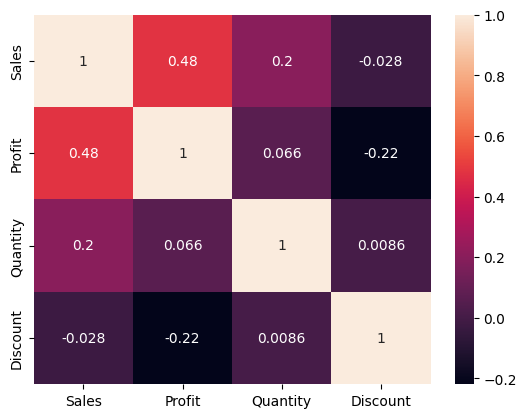

In [17]:
import seaborn as sns 
import matplotlib.pyplot as plt

sns.heatmap(corr,annot= True)
plt.show()

In [18]:
fast_products =df.groupby('Product_Name')['Quantity'].sum().sort_values(ascending=False).head(10)
print(fast_products)

Product_Name
Staples                                                       215
Staple envelope                                               170
Easy-staple paper                                             150
Staples in misc. colors                                        86
KI Adjustable-Height Table                                     74
Storex Dura Pro Binders                                        71
Avery Non-Stick Binders                                        71
GBC Premium Transparent Covers with Diagonal Lined Pattern     67
Situations Contoured Folding Chairs, 4/Set                     64
Staple-based wall hangings                                     62
Name: Quantity, dtype: int64


In [29]:
print(df.columns)

Index(['Row_ID', 'Order_ID', 'Order_Date', 'Ship_Date', 'Ship_Mode',
       'Customer_ID', 'Customer_Name', 'Segment', 'Country', 'City', 'State',
       'Postal_Code', 'Region', 'Product_ID', 'Category', 'Sub-Category',
       'Product_Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')


In [ ]:
slow_products= df.groupby('Product_Name')['Quantity'].sum().sort_values().head(10)
print('slow_products')

slow_products


In [31]:
slow_products

Product_Name
Penpower WorldCard Pro Card Scanner                                          1
Global Enterprise Series Seating Low-Back Swivel/Tilt Chairs                 1
Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order    1
Boston 1900 Electric Pencil Sharpener                                        1
Xerox 20                                                                     1
Grip Seal Envelopes                                                          2
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac             2
Xerox 1984                                                                   2
Avery Hi-Liter Pen Style Six-Color Fluorescent Set                           2
PNY Rapid USB Car Charger - Black                                            2
Name: Quantity, dtype: int64

In [41]:
df['Order_Date']=pd.to_datetime(df['Order_Date'],format='mixed')
df['Month'] =df['Order_Date'].dt.month_name()

print(df[['Order_Date','Month']].head())

  Order_Date     Month
0 2016-11-08  November
1 2016-11-08  November
2 2016-06-12      June
3 2015-10-11   October
4 2015-10-11   October


In [43]:
monthly_sales =df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
April        137762.1286
August       159044.0630
December     325293.5035
February      59751.2514
January       94924.8356
July         147238.0970
June         152718.6793
March        205005.4888
May          155028.8117
November     352461.0710
October      200322.9847
September    307649.9457
Name: Sales, dtype: float64


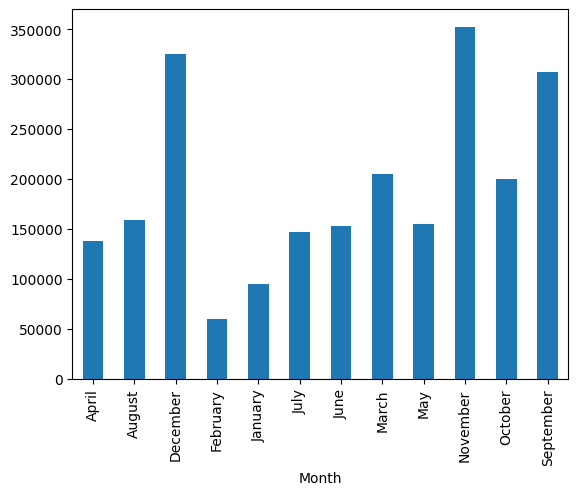

In [44]:
monthly_sales.plot(kind='bar')
plt.show()